In [ ]:
from astropy.io import fits as ft
data_loc = "/home/rohan/agn_photometry/sdss_data_plot_reproduction/data/dr16q_prop_May01_2024.fits"

In [ ]:
with ft.open(data_loc) as hdul:
    print(hdul.info())

In [ ]:
data_loc = "/home/rohan/agn_photometry/sdss_data_plot_reproduction/data/dr16q_prop_May01_2024.fits"
with ft.open(data_loc, memmap=True) as hdul:
    data = hdul[1].data
    xdata = data['FEII_OPT'].copy()  
    

In [ ]:
import fitsio
import polars as pl
import matplotlib.pyplot as plt
data_loc = "/home/rohan/agn_photometry/sdss_data_plot_reproduction/data/dr16q_prop_May01_2024.fits"
from astropy.table import Table
#table = Table.read(data_loc, hdu=1, memmap=True)
#print(table.colnames)
columns = ['FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'HBETA_BR', 'HBETA_BR_ERR', 'Z_FIT']
raw_data = fitsio.read(data_loc, ext=1, columns=columns)
df = pl.DataFrame({col: raw_data[col].tolist() for col in raw_data.dtype.names}).lazy()


In [ ]:
processed_df = (
    df
    .with_columns([
        pl.col("HBETA_BR").list.get(5).alias("HB_EW"),
        pl.col("HBETA_BR").list.get(4).alias("HB_FWHM"),
        pl.col("HBETA_BR_ERR").list.get(5).alias("HB_EW_ERR"),
    ])
    .with_columns([
        (pl.col("FEII_OPT_EW") / pl.col("HB_EW")).alias("R_Fe"),
        (((pl.col("FEII_OPT_EW_ERR") / pl.col("FEII_OPT_EW"))**2 + 
          (pl.col("HB_EW_ERR") / pl.col("HB_EW"))**2).sqrt()
        ).fill_nan(1.0).alias("rel_err_rfe")
    ])
    .filter(
        (pl.col("R_Fe") != 0) & 
        (pl.col("HB_FWHM") != 0) & 
        (pl.col("rel_err_rfe") < 0.20)
    )
    .collect()
)

In [ ]:
display_table = Table.from_pandas(processed_df.head(10).to_pandas())
print("Top 10 High-Quality Sources:")
print(display_table)

In [ ]:
print(df['HBETA_BR'][:,4]) #fhwm?

In [ ]:
print(table['HBETA_BR'][:,5]) #ew?

In [ ]:
print(table['FEII_OPT_EW'])

In [ ]:
import numpy as np
rfe =np.log(np.divide(table['FEII_OPT_EW'], table['HBETA_BR'][:,5], out = np.zeros_like(table['FEII_OPT_EW']), where=table['HBETA_BR'][:,5]!=0))
print(rfe)

In [ ]:
r_fe = processed_df["R_Fe"].to_numpy()
fwhm_ = processed_df["HB_FWHM"].to_numpy()

In [ ]:
r_fe

In [1]:
import fitsio
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
data_loc = "/home/rohan/agn_photometry/sdss_data_plot_reproduction/data/dr16q_prop_May01_2024.fits"
columns = ['FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'HBETA_BR', 'HBETA_BR_ERR', 'Z_FIT', 'LOGL5100']
raw_data = fitsio.read(data_loc, ext=1, columns=columns)
df = pl.DataFrame({col: raw_data[col].tolist() for col in raw_data.dtype.names}).lazy()
##data = Table.read(data_loc, hdu=1, memmap=True)
#fwhm_hbeta = data['HBETA_BR'][:,4].copy()
#fe_ew = data['FEII_OPT_EW'].copy()
#hb_ew = data['HBETA_BR'][:,5].copy()
#fe_err = data['FEII_OPT_EW_ERR'].copy()
#hb_err = data['HBETA_BR_ERR'][:, 5].copy()
#R_Fe =np.divide(fe_ew, hb_ew, out = np.zeros_like(fe_ew), where=hb_ew!=0)
#with np.errstate(divide='ignore', invalid='ignore'):
    #rel_err_rfe = np.sqrt((fe_err / fe_ew)**2 + (hb_err / hb_ew)**2)
    #rel_err_rfe = np.nan_to_num(rel_err_rfe, nan=1.0)

In [2]:
processed_df = (
    df.with_columns([
        pl.col("HBETA_BR").list.get(5).alias("hb_ew"),
        pl.col("HBETA_BR").list.get(4).alias("fwhm_hbeta"),
        pl.col("HBETA_BR_ERR").list.get(5).alias("hb_ew_err"),
    ])
    .with_columns([
        # R_Fe calculation
        (pl.col("FEII_OPT_EW") / pl.col("hb_ew")).alias("R_Fe"),
        # Relative error propagation
        (((pl.col("FEII_OPT_EW_ERR") / pl.col("FEII_OPT_EW")).pow(2) + 
          (pl.col("hb_ew_err") / pl.col("hb_ew")).pow(2)).sqrt()
        ).fill_nan(1.0).alias("rel_err_rfe")
    ])
    .filter(
        (pl.col("R_Fe") != 0) & 
        (pl.col("fwhm_hbeta") != 0) & 
        (pl.col("rel_err_rfe") < 0.20)
    )
    .collect()
)

In [3]:
R_Fe_filtered = processed_df["R_Fe"].to_numpy()
fwhm_filtered = processed_df["fwhm_hbeta"].to_numpy()
z_fit_filtered = processed_df["Z_FIT"].to_numpy()
logl5100_filtered = processed_df["LOGL5100"].to_numpy()

In [4]:
print(f"Total High-Quality Sources Isolated: {len(R_Fe_filtered)}")

Total High-Quality Sources Isolated: 26682


In [ ]:
#mask = (((R_Fe != 0)
        #&  (fwhm_hbeta != 0))
#& (rel_err_rfe<.20))

#R_Fe_filtered = R_Fe[mask]
#fwhm_filtered = fwhm_hbeta[mask]

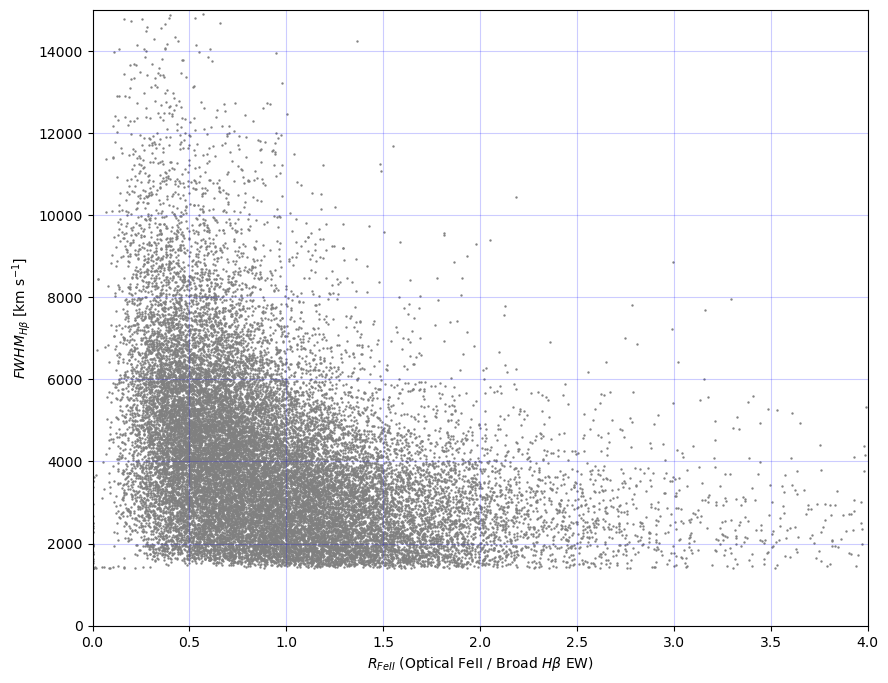

In [5]:
plt.figure(figsize=(10, 8))
plt.scatter(R_Fe_filtered, fwhm_filtered, color = 'gray', alpha=1, s=.5, rasterized = True)
plt.xlabel(r'$R_{FeII}$ (Optical FeII / Broad $H\beta$ EW)')
plt.ylabel(r'$FWHM_{H\beta}$ [km s$^{-1}$]')
plt.xlim(0, 4)
plt.ylim(0, 15000)
plt.grid(True, color='blue', alpha=0.2)
plt.show()

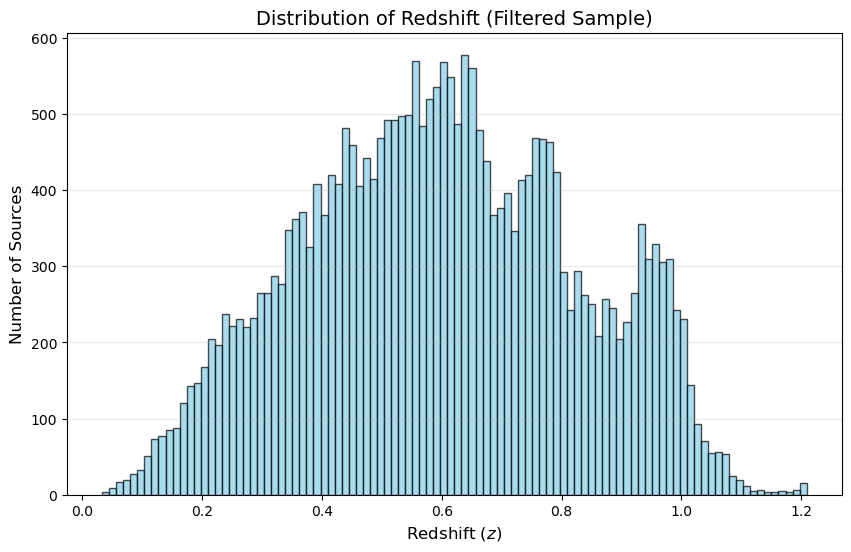

In [7]:
plt.figure(figsize=(10, 6))
#plt.hist(data['Z_FIT'][mask], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.hist(z_fit_filtered, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Redshift (Filtered Sample)', fontsize=14)
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

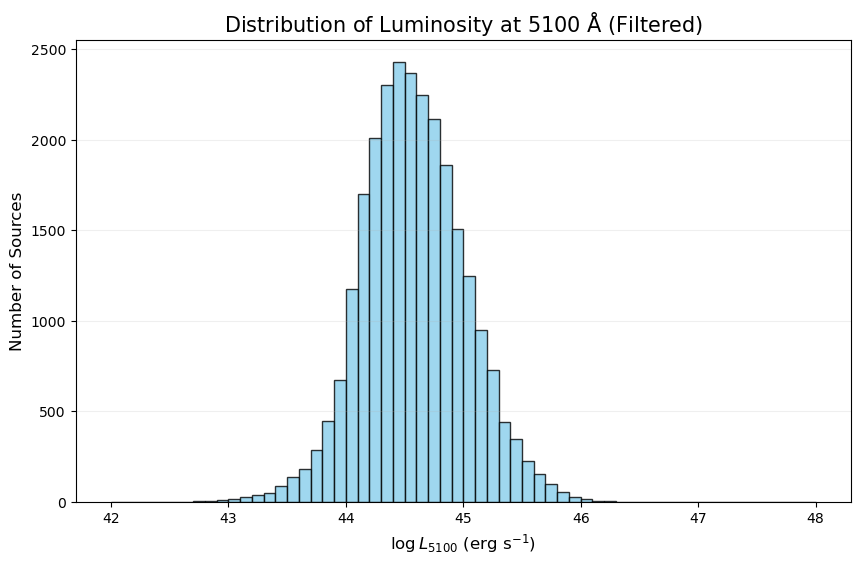

In [8]:
plt.figure(figsize=(10, 6))
#plt.hist(data['LOGL5100'][mask], bins=60, range=(42, 48), color='skyblue', edgecolor='black', alpha=0.8)
plt.hist(logl5100_filtered, bins=60, range=(42, 48), color='skyblue', edgecolor='black', alpha=0.8)
plt.title(r'Distribution of Luminosity at 5100 $\mathrm{\AA}$ (Filtered)', fontsize=15)
plt.xlabel(r'$\log L_{5100}$ ($\mathrm{erg\ s^{-1}}$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.2)
plt.show()

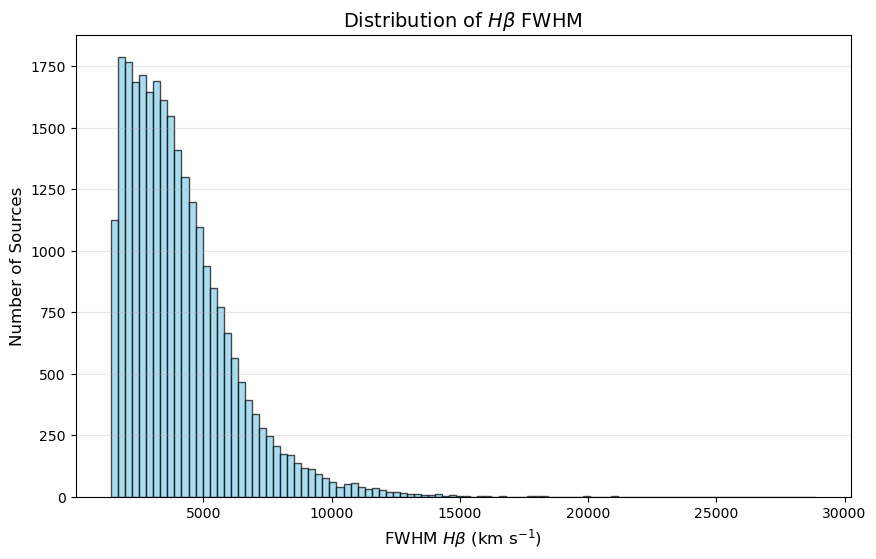

In [9]:
plt.figure(figsize=(10, 6))
#plt.hist(fwhm_hbeta[mask], bins=100
#         , color='skyblue', edgecolor='black', alpha=0.7)
plt.hist(fwhm_filtered, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of $H\\beta$ FWHM', fontsize=14)
plt.xlabel('FWHM $H\\beta$ (km s$^{-1}$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_551/1848721712.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


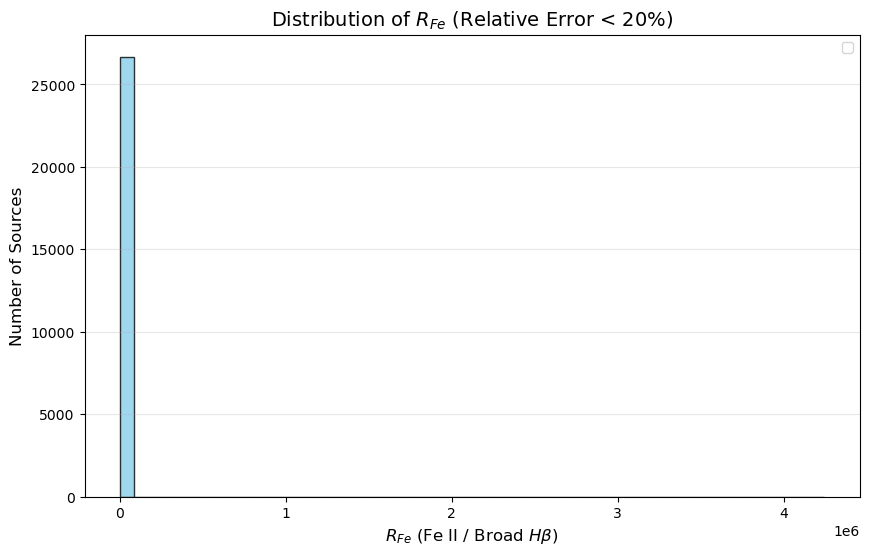

In [11]:
plt.figure(figsize=(10, 6))
#plt.hist(R_Fe[mask], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.hist(R_Fe_filtered, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of $R_{Fe}$ (Relative Error < 20%)', fontsize=14)
plt.xlabel('$R_{Fe}$ (Fe II / Broad $H\\beta$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
#plt.xlim(0, 4) 
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

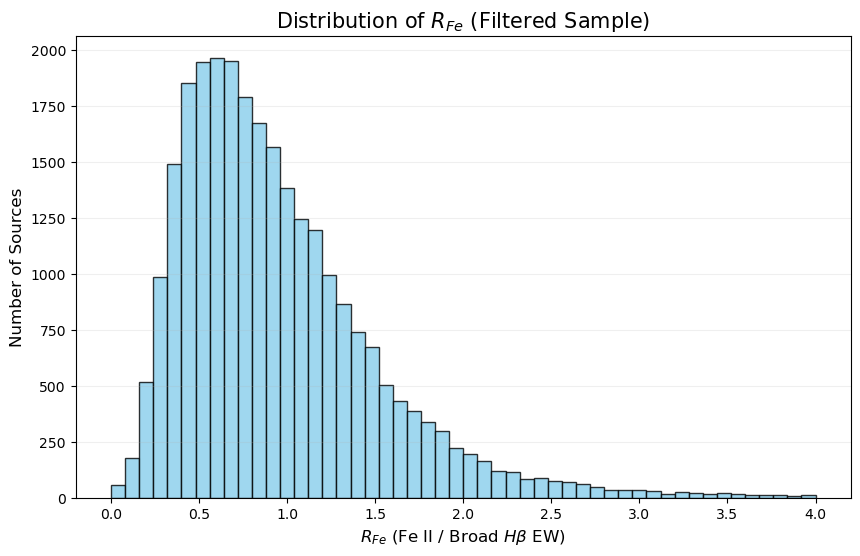

Total High-Quality Sources: 26682


In [13]:
plt.figure(figsize=(10, 6))
#plt.hist(R_Fe[mask], bins=50, range=(0, 4), color='skyblue', edgecolor='black', alpha=0.8)
plt.hist(R_Fe_filtered, bins=50, range=(0, 4), color='skyblue', edgecolor='black', alpha=0.8)
plt.title(r'Distribution of $R_{Fe}$ (Filtered Sample)', fontsize=15)
plt.xlabel(r'$R_{Fe}$ (Fe II / Broad $H\beta$ EW)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.2)
plt.show()
#print(f"Total High-Quality Sources: {np.sum(mask)}")
print(f"Total High-Quality Sources: {len(R_Fe_filtered)}")